
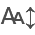

In [10]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

from importlib import reload

import itables

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

sys.path.append('../scripts')

import small_utilities
reload(small_utilities)
import Block_analysis
reload(Block_analysis)

from Block_analysis import *
from small_utilities import *

import seaborn as sns

In [2]:
def reposition_first(array):
    if len(array.shape) == 2:  # Check if it's 2D
        # Reposition first row to the last
        return np.vstack((array[1:], array[0]))
    elif len(array.shape) == 3:  # Check if it's 3D
        # Reposition first slice to the last
        return np.concatenate((array[1:], array[:1]), axis=0)

import matplotlib.pyplot as plt
import numpy as np

def plot_colvar(colvar, trj_frames, num_cvs, labels, weights=None, out_dir=None):
    """
    Plot collective variables over time with corresponding histograms and reweighted histograms.

    Parameters:
        colvar (np.ndarray): Array of collective variables with time as the first column.
        trj_frames (dict): Dictionary mapping frame indices to frame times.
        num_cvs (int): Number of collective variables.
        labels (dict): Dictionary of labels for the collective variables.
        weights (np.ndarray, optional): Normalized weights for reweighting histograms. Must match the number of frames.
        out_dir (str, optional): Directory to save the plot. If None, the plot is shown but not saved.
    """
    # Configure subplots
    height_ratios = [1] * (num_cvs - 1)
    fig, axes = plt.subplots(
        num_cvs - 1, 2, figsize=(32, 40),
        gridspec_kw={
            'width_ratios': [4, 1],
            'height_ratios': height_ratios,
            'left': 0.1, 'right': 0.9,
            'bottom': 0.1, 'top': 0.9,
            'wspace': 0.02, 'hspace': 0.2
        },
        sharey=False,
        # sharex=True
    )

    # Check if weights are provided
    if weights is not None:
        if len(weights) != colvar.shape[0]:
            raise ValueError("Weights must match the number of frames in colvar.")
        weights = weights / np.sum(weights)  # Normalize weights

    # Loop over collective variables
    for i in range(num_cvs - 1):
        time = colvar.T[0] / 10**5  # Time in appropriate units
        data = colvar.T[i + 1]  # Data for the i-th collective variable

        # Line plot of collective variable over time
        axes[i, 0].plot(time, data, color='r', label=labels.get(str(i + 1), f'CV {i + 1}'))
        axes[i, 0].set_ylabel(labels.get(str(i + 1), f'CV {i + 1}'), size=35)
        axes[i, 0].set_xlabel(r"Time ($\mu$s)", size=35)
        axes[i, 0].tick_params(labelsize=25)
        xticks=[frame_time[1] / 10**5 for frame_idx, frame_time in trj_frames.items()]

        axes[i, 0].set_xticks(xticks)

        # Add vertical lines for trajectory frames
        for frame_idx, frame_time in trj_frames.items():
            axes[i, 0].axvline(x=frame_time[1] / 10**5, color='black', linewidth=3, linestyle='--')

        # Plot histogram
        axes[i, 1].hist(data, bins=50, orientation='horizontal', density=True, color='black', histtype='step', linewidth=2)

        # Plot reweighted histogram (if weights are provided)
        if weights is not None:
            # # Compute weighted histogram
            # hist, bin_edges = np.histogram(data, bins=50, density=True, weights=weights)
            # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            # axes[i, 1].plot(hist, bin_centers, color='green', linewidth=2, label='Reweighted')
            axes[i, 1].hist(data, bins=50, orientation='horizontal', density=True, color='green', histtype='step', linewidth=2, weights=weights)


        axes[i, 1].tick_params(labelsize=25)
        axes[i, 1].set_yticks([])

    # Save or display the plot
    if out_dir:
        plt.savefig(f"{out_dir}/cv_plot.png", dpi=310, bbox_inches='tight')
    else:
        plt.show()

def create_trj_frames(colvar_data, nreps=16):
    """
    Create trajectory frame intervals based on the given data.

    Parameters:
        colvar_data (list): A list or array-like structure containing the data.
        nreps (int): Number of intervals (default is 16).
        index (int): Index of the dataset to process (default is 100).

    Returns:
        dict: A dictionary where keys are strings of interval indices and values are lists of start and end points.
    """
    # Determine the total length and calculate interval size
    total_frames = colvar_data.shape[0] - 1
    interval_size = total_frames / nreps

    # Initialize variables
    a, b = 0, interval_size
    trj_frames = {}

    # Create intervals
    for i in range(nreps):
        trj_frames[str(i)] = [a, b]
        a = b
        b += interval_size

    return trj_frames

def free_energy_2D_blockerror(Y, X, bins=None, T:int=None, y0:float=None, ymax:float=None, x0:float=None,
                   xmax:float=None, weights=None, blocks=10):
    
    histo, xedges, yedges = np.histogram2d(
        Y, X, bins, [[y0, ymax], [x0, xmax]], density=True, weights=weights
    )
    # max = np.max(histo)
    # free_energy=-(0.001987*T)*np.log(histo)
    free_energy = -(0.001987*T)*np.log(np.flipud(histo)+.000001)
    free_energy = free_energy-np.min(free_energy)

    xcenters = xedges[:-1] + np.diff(xedges)/2
    ycenters = yedges[:-1] + np.diff(yedges)/2

    Ind = chunkIt(len(Y), blocks)
    block_size = (Ind[0][1]-Ind[0][0])
    hist_blocks = []
    # for i in range(0, len(Ind)):
    for i in np.arange(0, blocks):

        block_data_Y = Y[Ind[i][0]:Ind[i][1]]
        block_data_X = X[Ind[i][0]:Ind[i][1]]

        if weights is not None: block_weights = weights[Ind[i][0]:Ind[i][1]]
        else: block_weights = None

        hist, xedges, yedges = np.histogram2d(
            block_data_Y, block_data_X, bins, [[y0, ymax], [x0, xmax]], density=True, weights=block_weights
        )
        # hist, binedges = np.histogram(block_data, bins=bins, range=[
        #                             x0, xmax], density=True, weights=weights[Ind[i][0]:Ind[i][1]])
        hist_blocks.append(hist)
        
    hist_blocks = np.array(hist_blocks)
    average = np.average(hist_blocks, axis=0)
    variance = np.var(hist_blocks, axis=0)
    N = len(hist_blocks)
    error = np.sqrt(variance / N)
    ferr = -(0.001987*T)*(error / average)

    return free_energy, xcenters, ycenters, ferr, error

def adjust_min(x):
    idx = (x == 0)
    x[idx] = x[~idx].min()
    return x

def blocking_2d_hist(Y, X, y0:float=None, ymax:float=None, x0:float=None,
                   xmax:float=None, weights=None, chunk_width=10, bin_count=35):
    """blocking_2d_hist used to produce individual 2D histograms of chunk_width
    blocks of data. The width needs to be identified from reblocking analysis of
    each 2D variable. Bin count is up to you, but should be the same for all."""
    
    import numpy as np
    from Block_analysis import chunkIt

    assert len(Y) == len(X), "Y and X must have the same length"
    chunks = chunkIt(len(Y), chunk_width)
    bounds=np.array([[y0, ymax], [x0, xmax]]) + np.array([[-0.01, 0.01], [-0.01, 0.01]])
    bins = [np.linspace(bounds[0][0], bounds[0][1], bin_count+1),
            np.linspace(bounds[1][0], bounds[1][1], bin_count+1)]
    flattened_histos = np.zeros((bin_count**2,len(chunks)))

    for i, chunk in enumerate(chunks):
        histo, _, _ = np.histogram2d(
                            Y[chunk[0]:chunk[1]], 
                            X[chunk[0]:chunk[1]], 
                            bins, 
                            bounds, 
                            density=False, 
                            weights=weights[chunk[0]:chunk[1]] if weights is not None else None
                            )   
        flattened_histos[:, i] = histo.flatten()
    xcenters = (bins[0][1:]+bins[0][:-1])/2
    ycenters = (bins[1][1:]+bins[1][:-1])/2

    return flattened_histos/chunk_width, xcenters, ycenters

def blocking_bootstrap_2d_fe(X, Y, bin_count,y0, ymax, x0, xmax,weights=None):

    import numpy as np
    import pyblock as pb
    from scipy.stats import bootstrap

    assert len(Y) == len(X), "Y and X must have the same length"

    if not isinstance(X, np.ndarray):
        X = np.array(X)
    if not isinstance(Y, np.ndarray):
        Y = np.array(Y)

    
    reblock_data_X = pb.blocking.reblock(X, weights=weights)
    reblock_data_Y = pb.blocking.reblock(Y, weights=weights)

    opt_X = pb.blocking.find_optimal_block(
        len(X), reblock_data_X)[0]
    opt_Y = pb.blocking.find_optimal_block(
        len(Y), reblock_data_Y)[0]

    # print(opt_X, opt_Y)
    # block_length = reblock_data_X[opt_X].ndata if \
    #             reblock_data_X[opt_X].ndata > reblock_data_X[opt_Y].ndata \
    #                     else reblock_data_Y[opt_Y].ndata


    # print('Optimal block size for X:', reblock_data_X[opt_X].ndata)
    # print('Optimal block size for Y:', reblock_data_Y[opt_Y].ndata)

    # block_length = input("Enter the desired block length: ")
    # block_length = int(block_length)
    # if block_length <= 0:
    #     raise ValueError("Block length must be a positive integer.")
    block_length = reblock_data_X[opt_X].ndata if \
                reblock_data_X[opt_X].ndata > reblock_data_Y[opt_Y].ndata \
                        else reblock_data_Y[opt_Y].ndata
    
    skip = len(X) % block_length
    
    # print('Block length:', block_length)
    # print('Skip:', skip)

    options = {'Y':Y[skip:], 'X':X[skip:], 'y0':y0, 'ymax':ymax, 'x0':x0, 'xmax':xmax, 
                'chunk_width':block_length, 'bin_count':bin_count, 'weights': weights,}

    hist_2d_for_fe, xcenters, ycenters = blocking_2d_hist(**options)

    def fe2D(x): 
        p = np.sum(x, axis=-1)/len(x)
        fe = -(0.001987*300)*np.log(p+0.000000001)
        return fe

    bootstrap_results = bootstrap((hist_2d_for_fe.T,), fe2D, n_resamples=1000, method='percentile')

    return bootstrap_results, xcenters, ycenters

## Analysis for $\alpha$-synuclien with Fasudil (Trajectory-1)

### Loading the data

The colvar files are generated from the concatinated trajectories at the respective time intervels. For example, $100ns$ for each replica trajectory is obtained and concatinated togeather, which is used to compute the weights. 

In [3]:
# work_directory = os.getcwd()
work_directory = '/data/jk_ssREST3_repo_data/data/PBMetaD/'
a = np.sort([i for i in os.listdir(work_directory) if os.path.isdir(f'{work_directory}/{i}')])

print(f'Current working dir: \n{work_directory}\n')
print(f'which has the following directories: \n{a}')
print(os.getcwd())

Current working dir: 
/data/jk_ssREST3_repo_data/data/PBMetaD/

which has the following directories: 
['apo_1' 'apo_2' 'fas_1' 'fas_2' 'lig47_1' 'lig47_2']
/home/jayakrishna/Github/ssREST3/Fasudil


In [4]:
index_dict={
    'Rg':1, 'H-bond':2, 'Helix-right':3, 'Betasheet':4, 'Helix-left':5, 'Polypro':6,
    'Dist-1':7, 'Dist-2':8, 'Dist-3':9, 'Dist-4':10, 'Dist-5':11, 'Dist-6':12
       }

In [5]:
colvar_data={}
weights_norm={}

for i in range(0,1000, 100):

    if i==0:
        colvar_data[i+1000]=np.loadtxt(f'{work_directory}/{a[2]}/colvar/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i+1000] = norm_weights(f'{work_directory}/{a[2]}/colvar/colvar_{i}.dat')
        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i+1000])}")
        print(f"Number of frames : {colvar_data[i+1000].shape[0]}")
    else:
            
        colvar_data[i]=np.loadtxt(f'{work_directory}/{a[2]}/colvar/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i] = norm_weights(f'{work_directory}/{a[2]}/colvar/colvar_{i}.dat')

        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i])}")
        print(f"Number of frames : {colvar_data[i].shape[0]}")
    


Sum of combined xtc weights : 1.0
Number of frames : 1600001
Sum of combined xtc weights : 0.9999999999999998
Number of frames : 160001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 320001
Sum of combined xtc weights : 1.0
Number of frames : 480001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 640001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 800001
Sum of combined xtc weights : 0.9999999999999993
Number of frames : 960001
Sum of combined xtc weights : 1.0
Number of frames : 1120001
Sum of combined xtc weights : 0.9999999999999998
Number of frames : 1280001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 1440001


### Plot for 100ns data (1600ns(1.6 $\mu$ s) aggregate time.)

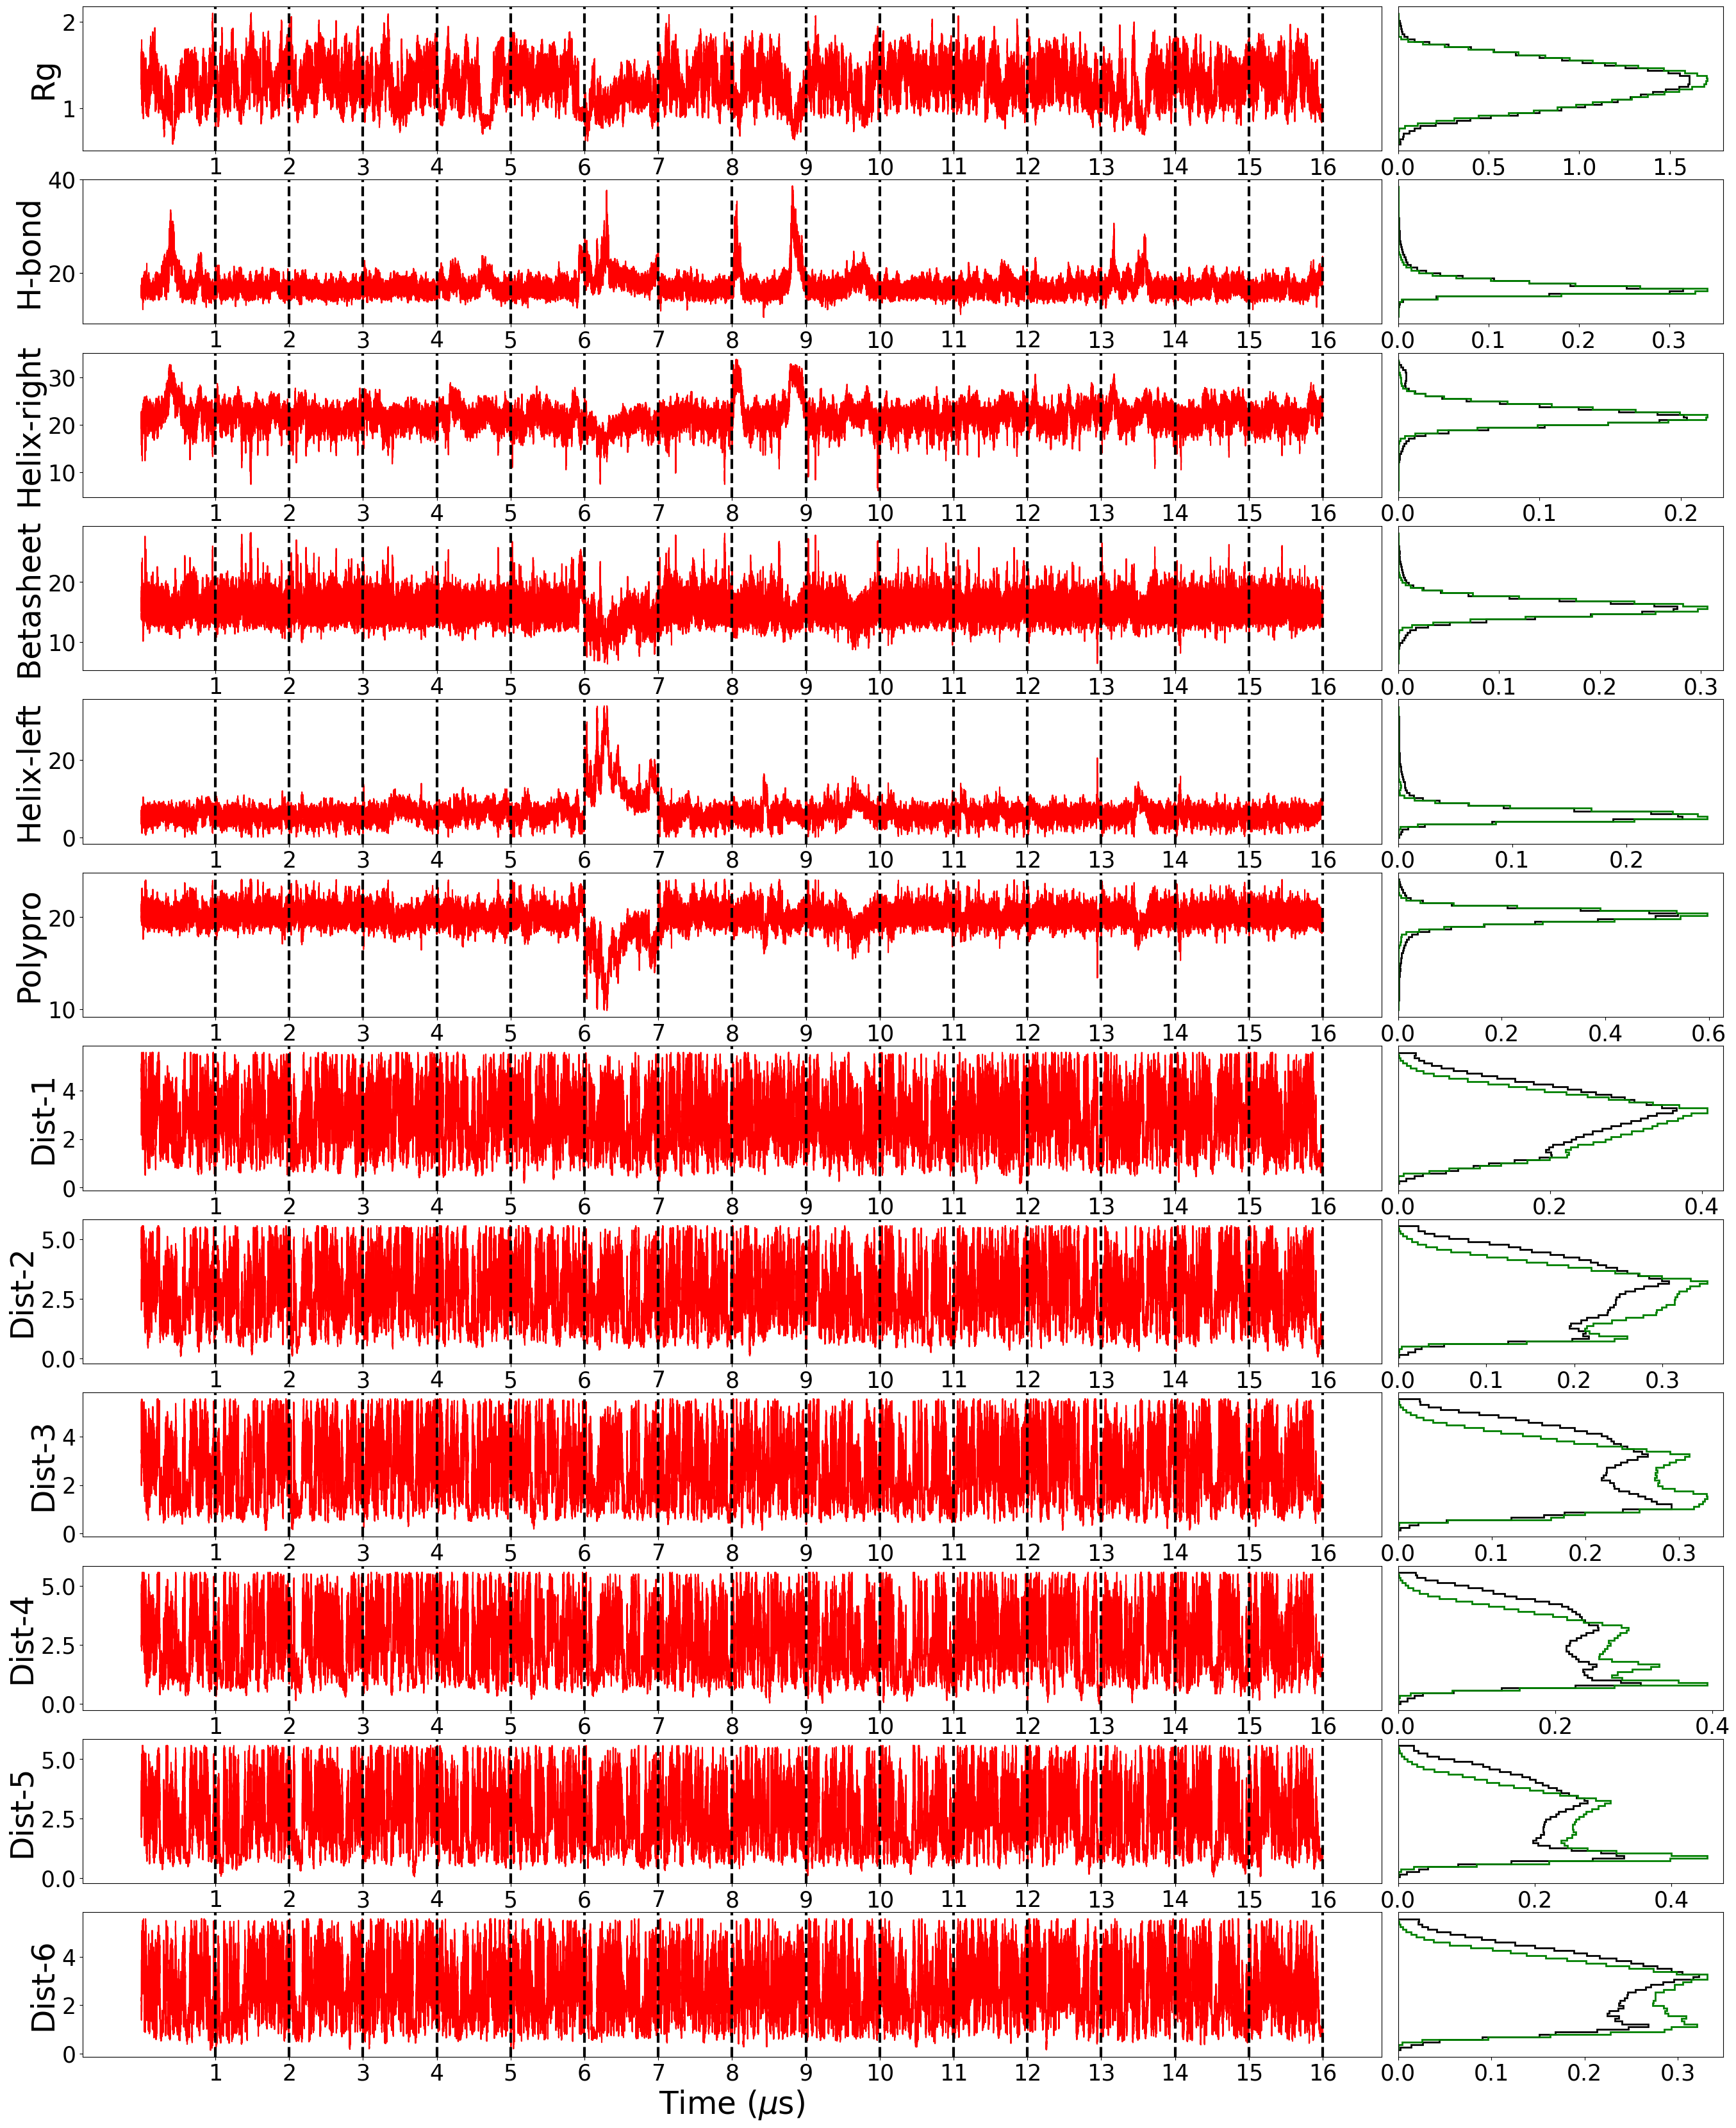

In [7]:
label={
    '1':'Rg', '2':'H-bond', '3':'Helix-right', '4':'Betasheet', '5':'Helix-left', '6':'Polypro',
    '7':'Dist-1', '8':'Dist-2', '9':'Dist-3', '10':'Dist-4', '11':'Dist-5', '12':'Dist-6'
       }

# change the value of index from 100 to 1000 to see the plot for the different aggregate data
index=1000
trj_frames=create_trj_frames(colvar_data[index])

plot_colvar(colvar_data[index], trj_frames, num_cvs, labels=label, weights=weights_norm[index])

### Free energy plot of Rg computed plotted from the respective colver files

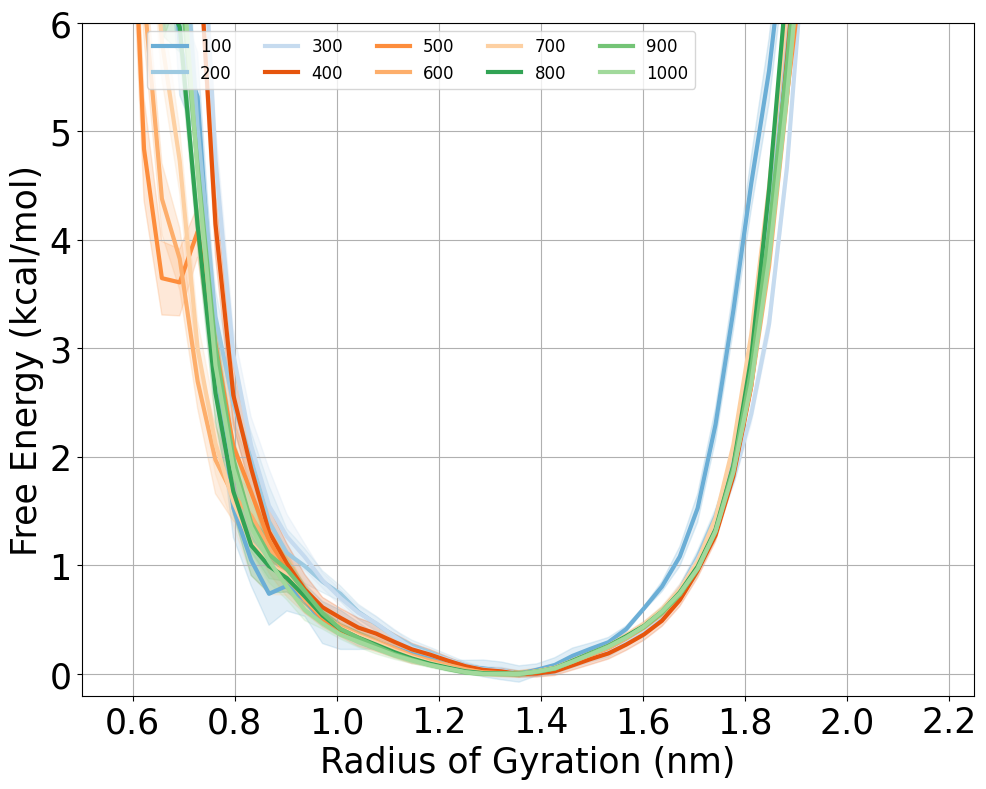

In [9]:
np.seterr(invalid='ignore')

plt.figure(figsize=(10,8))

for i in range(100,1100, 100):
    dG1, bin_centers, ferr = free_energy_1D_blockerror(colvar_data[i].T[index_dict['Rg']], T=300, x0=0.5, xmax=2.25, bins=50, blocks=5, weights=weights_norm[i])

    sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=str(i), linestyle='-')
    plt.fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

plt.ylim(-0.2, 6)
plt.xlim(0.5, 2.25)
plt.xlabel('Radius of Gyration (nm)', size=25)
plt.ylabel('Free Energy (kcal/mol)', size=25)
plt.legend(loc='upper center', fontsize=12, ncol=5, bbox_to_anchor=(0.38, 1.0))
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.title(f"Replica : {val}", size=20)
plt.tight_layout()
plt.grid()
plt.show()

In [10]:
mean_rg=np.zeros((10,2))
# mean_rg_err=np.zeros(10)

for i in range(100,1100, 100):
    # print(f'{i} : {get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[1], weights_norm[i])}')
    mean_rg[int(i/100)-1]=get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[index_dict['Rg']], weights_norm[i])

mean_rg

array([[1.2747962 , 0.03032597],
       [1.33180877, 0.01547839],
       [1.33402035, 0.01312823],
       [1.32356838, 0.01753654],
       [1.30346639, 0.01331816],
       [1.30250254, 0.0138523 ],
       [1.2959406 , 0.01128472],
       [1.29694805, 0.01179085],
       [1.30189638, 0.01018558],
       [1.29434735, 0.01046727]])

### $<Rg>$ plotted against aggregate time

Text(0, 0.5, '<Rg> (nm)')

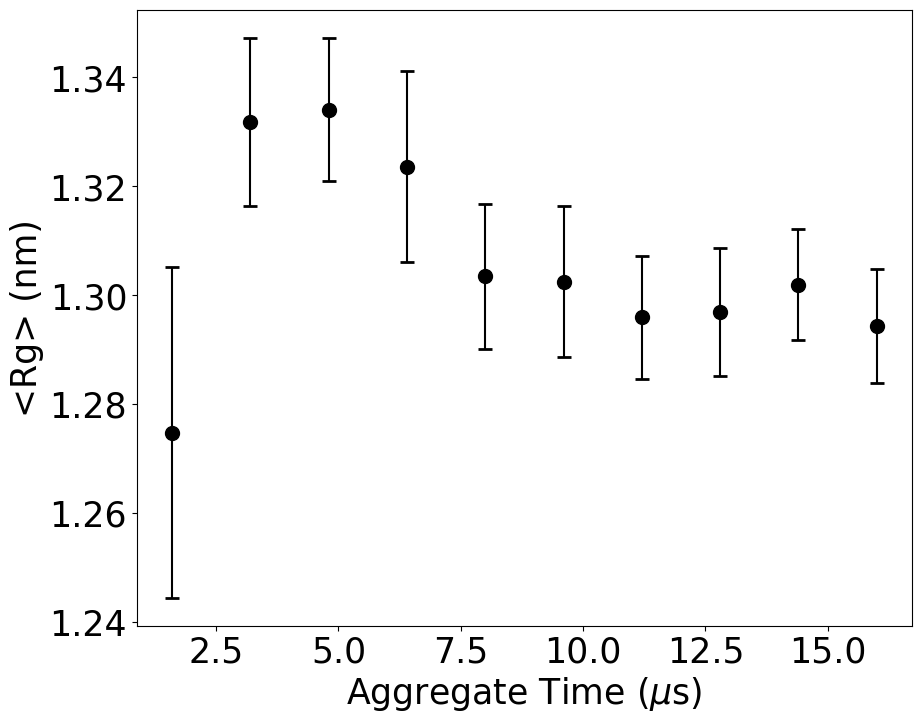

In [11]:
plt.figure(figsize=(10,8))

plt.errorbar(np.arange(0.1,1.1,0.1)*16, mean_rg.T[0], yerr=mean_rg.T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)

plt.tick_params(labelsize=25)
plt.xlabel(r'Aggregate Time ($\mu$s)', size=25)
plt.ylabel(r'<Rg> (nm)', size=25)


### Free energy for 6 distances computed between protein and small molecule

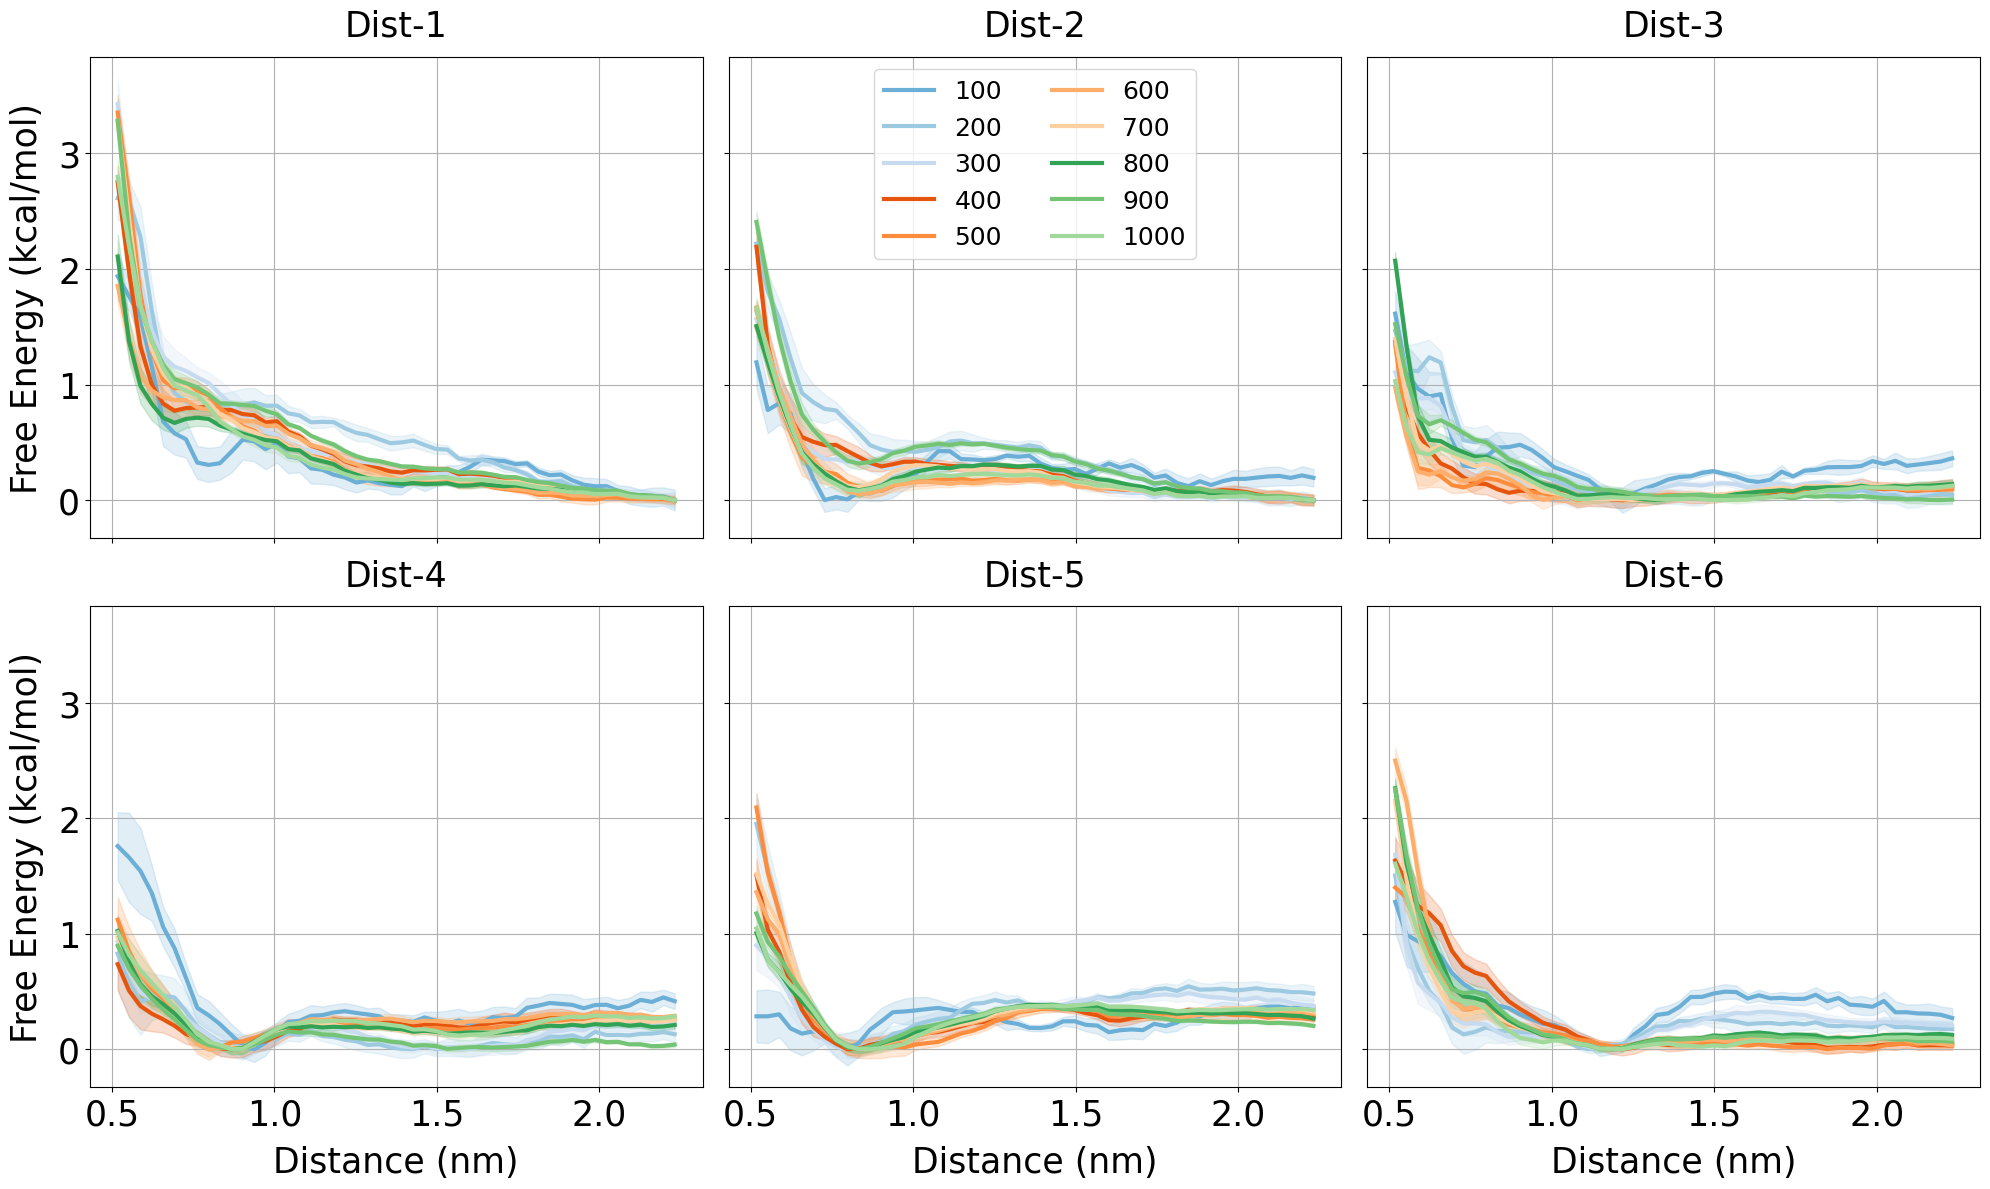

In [12]:
np.seterr(invalid='ignore')

fig, ax = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)

for d in range(0,6):

    p,q = np.unravel_index(d,(2,3))

    for i in range(100,1100, 100):
        dG1, bin_centers, ferr = free_energy_1D_blockerror(colvar_data[i].T[d+7], T=300, x0=0.5, xmax=2.25, bins=50, blocks=5, weights=weights_norm[i])

        sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=str(i), linestyle='-', ax=ax[p,q])
        ax[p,q].fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

    ax[p,q].tick_params(labelsize=25)
    # ax[p,q].set_ylim(-0.2, 2)
    # ax[p,q].set_xlim(0.5, 2.25)
    ax[p,q].set_xlabel(f'Distance (nm)', size=25, labelpad=10)
    ax[p,q].set_ylabel('Free Energy (kcal/mol)', size=25, labelpad=10)
    if p==0 and q==1 : ax[p,q].legend(loc='upper center', fontsize=18, ncol=2)
    else : ax[p,q].legend().set_visible(False)
    ax[p,q].set_title(f'Dist-{d+1}', size=25, pad=15)
    ax[p,q].grid()


plt.tight_layout()


### Weighted average of distance plotted against aggregate time

In [13]:
mean_dist=np.zeros((6,10,2))
# mean_rg_err=np.zeros(10)

for d in range(0,6):
        
    for i in range(100,1100, 100):
        # print(f'{i} : {get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[1], weights_norm[i])}')
        mean_dist[d][int(i/100)-1]=get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[d+7], weights_norm[i])





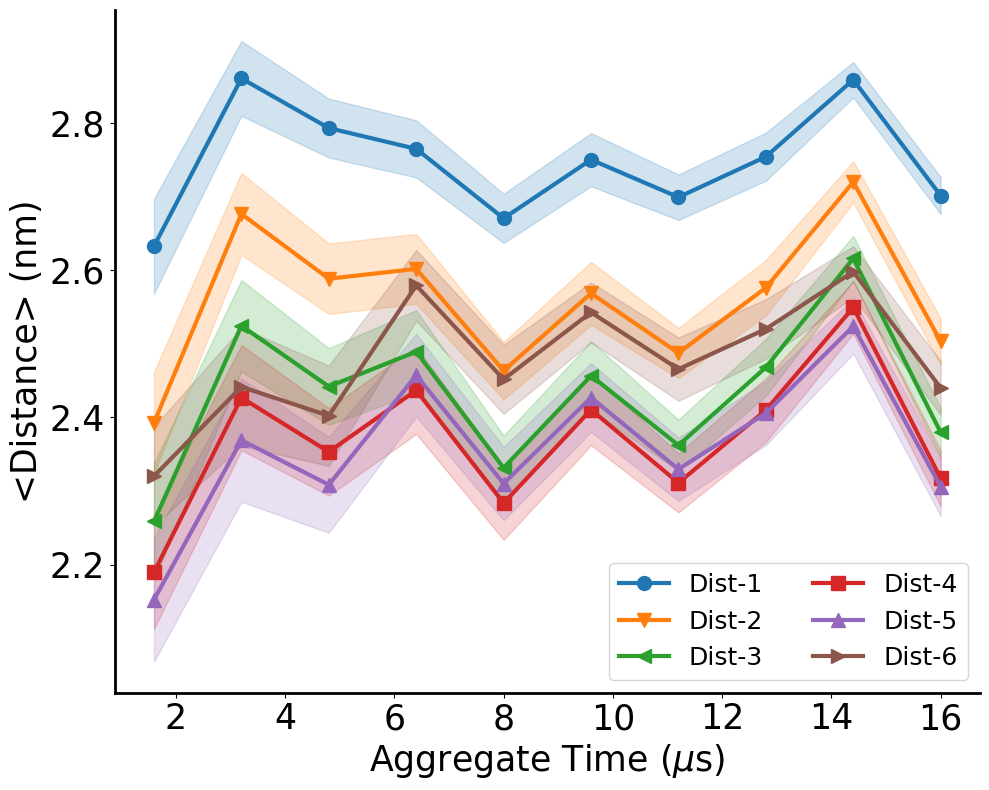

In [14]:
marker=['o','v','<', 's','^','>']

fig, ax = plt.subplots(figsize=(10,8))  # Create a figure and an axes

for d in range(0,6):
    # plt.errorbar(np.arange(0.1,1.1,0.1)*16, mean_dist[d].T[0], yerr=mean_dist[d].T[1], fmt='o', color=plt.cm.tab10(d), markersize=10, capsize=5, capthick=2, label=f'Dist-{d+1}')
    ax.plot(np.arange(0.1,1.1,0.1)*16, mean_dist[d].T[0], color=plt.cm.tab10(d), linewidth=3, label=f'Dist-{d+1}', marker=marker[d], markersize=10)
    ax.fill_between(np.arange(0.1,1.1,0.1)*16, mean_dist[d].T[0]-mean_dist[d].T[1], mean_dist[d].T[0]+mean_dist[d].T[1], color=plt.cm.tab10(d), alpha=0.2)

ax.tick_params(labelsize=25)
ax.set_xlabel(r'Aggregate Time ($\mu$s)', size=25)
ax.set_ylabel(r'<Distance> (nm)', size=25)
ax.legend(fontsize=18, ncol=2)

ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()

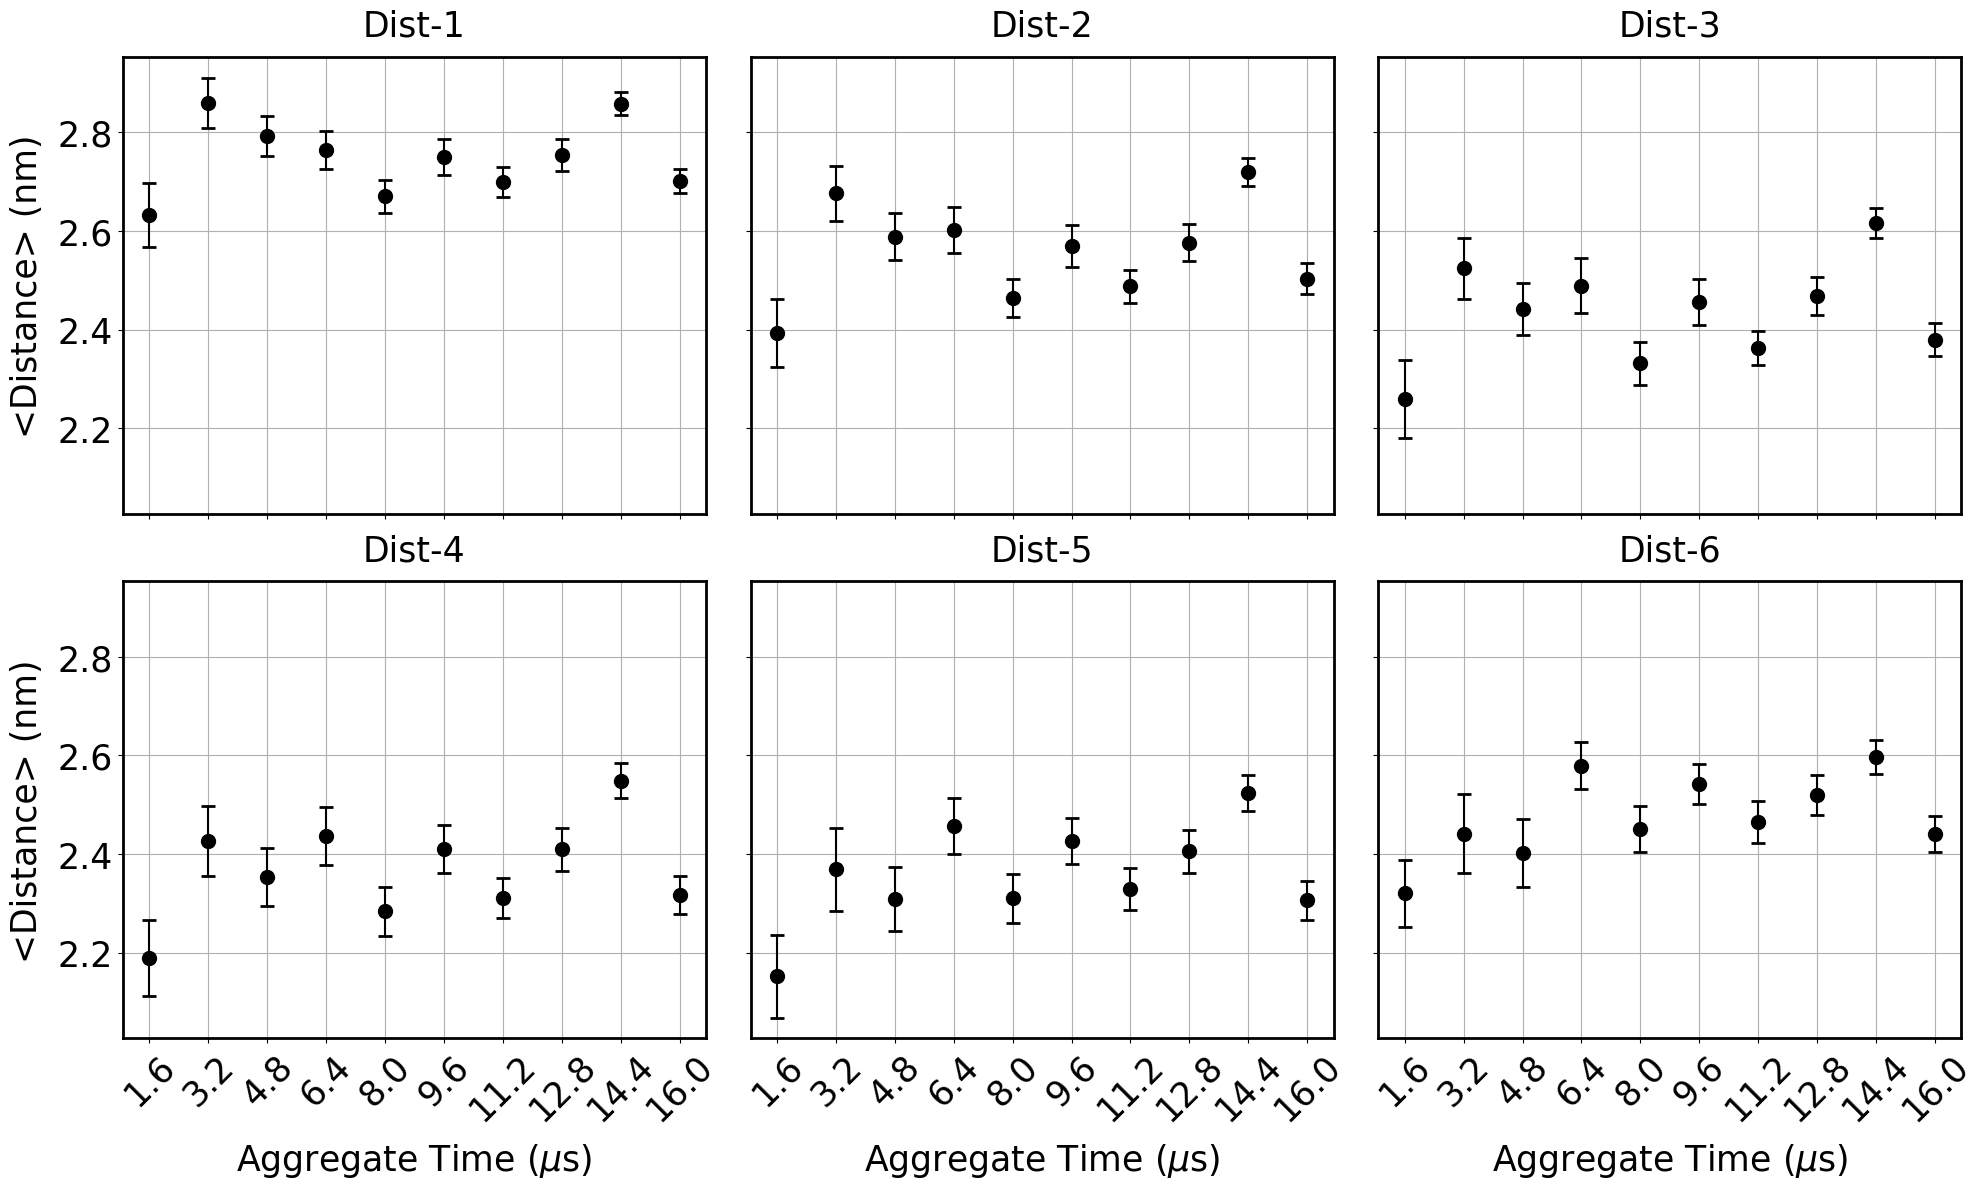

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)

for d in range(0,6):

    p,q = np.unravel_index(d,(2,3))

    ax[p,q].errorbar(np.arange(0.1,1.1,0.1)*16, mean_dist[d].T[0], yerr=mean_dist[d].T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)


    ax[p,q].tick_params(labelsize=25)
    # ax[p,q].set_ylim(-0.2, 2)
    # ax[p,q].set_xlim(0.5, 2.25)
    if p==1 : ax[p,q].set_xlabel(r'Aggregate Time ($\mu$s)', size=25, labelpad=10)
    if q==0 :ax[p,q].set_ylabel(r'<Distance> (nm)', size=25, labelpad=10)

    ax[p,q].set_title(f'Dist-{d+1}', size=25, pad=15)
    ax[p,q].grid()
    ax[p,q].spines['right'].set_linewidth(2)
    ax[p,q].spines['left'].set_linewidth(2)
    ax[p,q].spines['top'].set_linewidth(2)
    ax[p,q].spines['bottom'].set_linewidth(2)

    ax[p,q].set_xticks(np.arange(0.1,1.1,0.1)*16,[round(i,1) for i in np.arange(0.1,1.1,0.1)*16],rotation=45)


plt.tight_layout()


In [7]:
sequence=  ['ASP121', 'ASN122', 'GLU123', 'ALA124', 'TYR125', 'GLU126', 'MET127', 'PRO128', 'SER129', 'GLU130', 'GLU131', 'GLY132', 'TYR133', 'GLN134', 'ASP135',
'TYR136', 'GLU137', 'PRO138', 'GLU139', 'ALA140']

ticks_pnum , ticks_pname = sequence_ticks_1(sequence)


In [17]:
file_name = 'l_contact_map_re.json'

lcm_fas_1 = []
# lcm_fas_2 = []
# lcm_lig47_1 = []
# lcm_lig47_2 = []

for i in range(0, 1000, 100):
    lcm_fas_1.append(load_json(f'{work_directory}/{a[0]}/data/out_{i}/{file_name}'))
    # lcm_fas_2.append(load_json(f'{work_directory}/{a[1]}/data/out_{i}/{file_name}'))
    # lcm_lig47_1.append(load_json(f'{work_directory}/{a[2]}/data/out_{i}/{file_name}'))
    # lcm_lig47_2.append(load_json(f'{work_directory}/{a[3]}/data/out_{i}/{file_name}'))

lcm_fas_1 = np.array([lcm_fas_1[i]['0'] for i in range(len(lcm_fas_1))])
lcm_fas_1 = reposition_first(lcm_fas_1)

# lcm_fas_2 = np.array([lcm_fas_2[i]['0'] for i in range(len(lcm_fas_2))])
# lcm_fas_2 = reposition_first(lcm_fas_2)

# lcm_lig47_1 = np.array([lcm_lig47_1[i]['0'] for i in range(len(lcm_lig47_1))])
# lcm_lig47_1 = reposition_first(lcm_lig47_1)

# lcm_lig47_2 = np.array([lcm_lig47_2[i]['0'] for i in range(len(lcm_lig47_2))])
# lcm_lig47_2 = reposition_first(lcm_lig47_2)

Text(0.5, 0.93, '$\\alpha$-synuclein C-term :Fasudil')

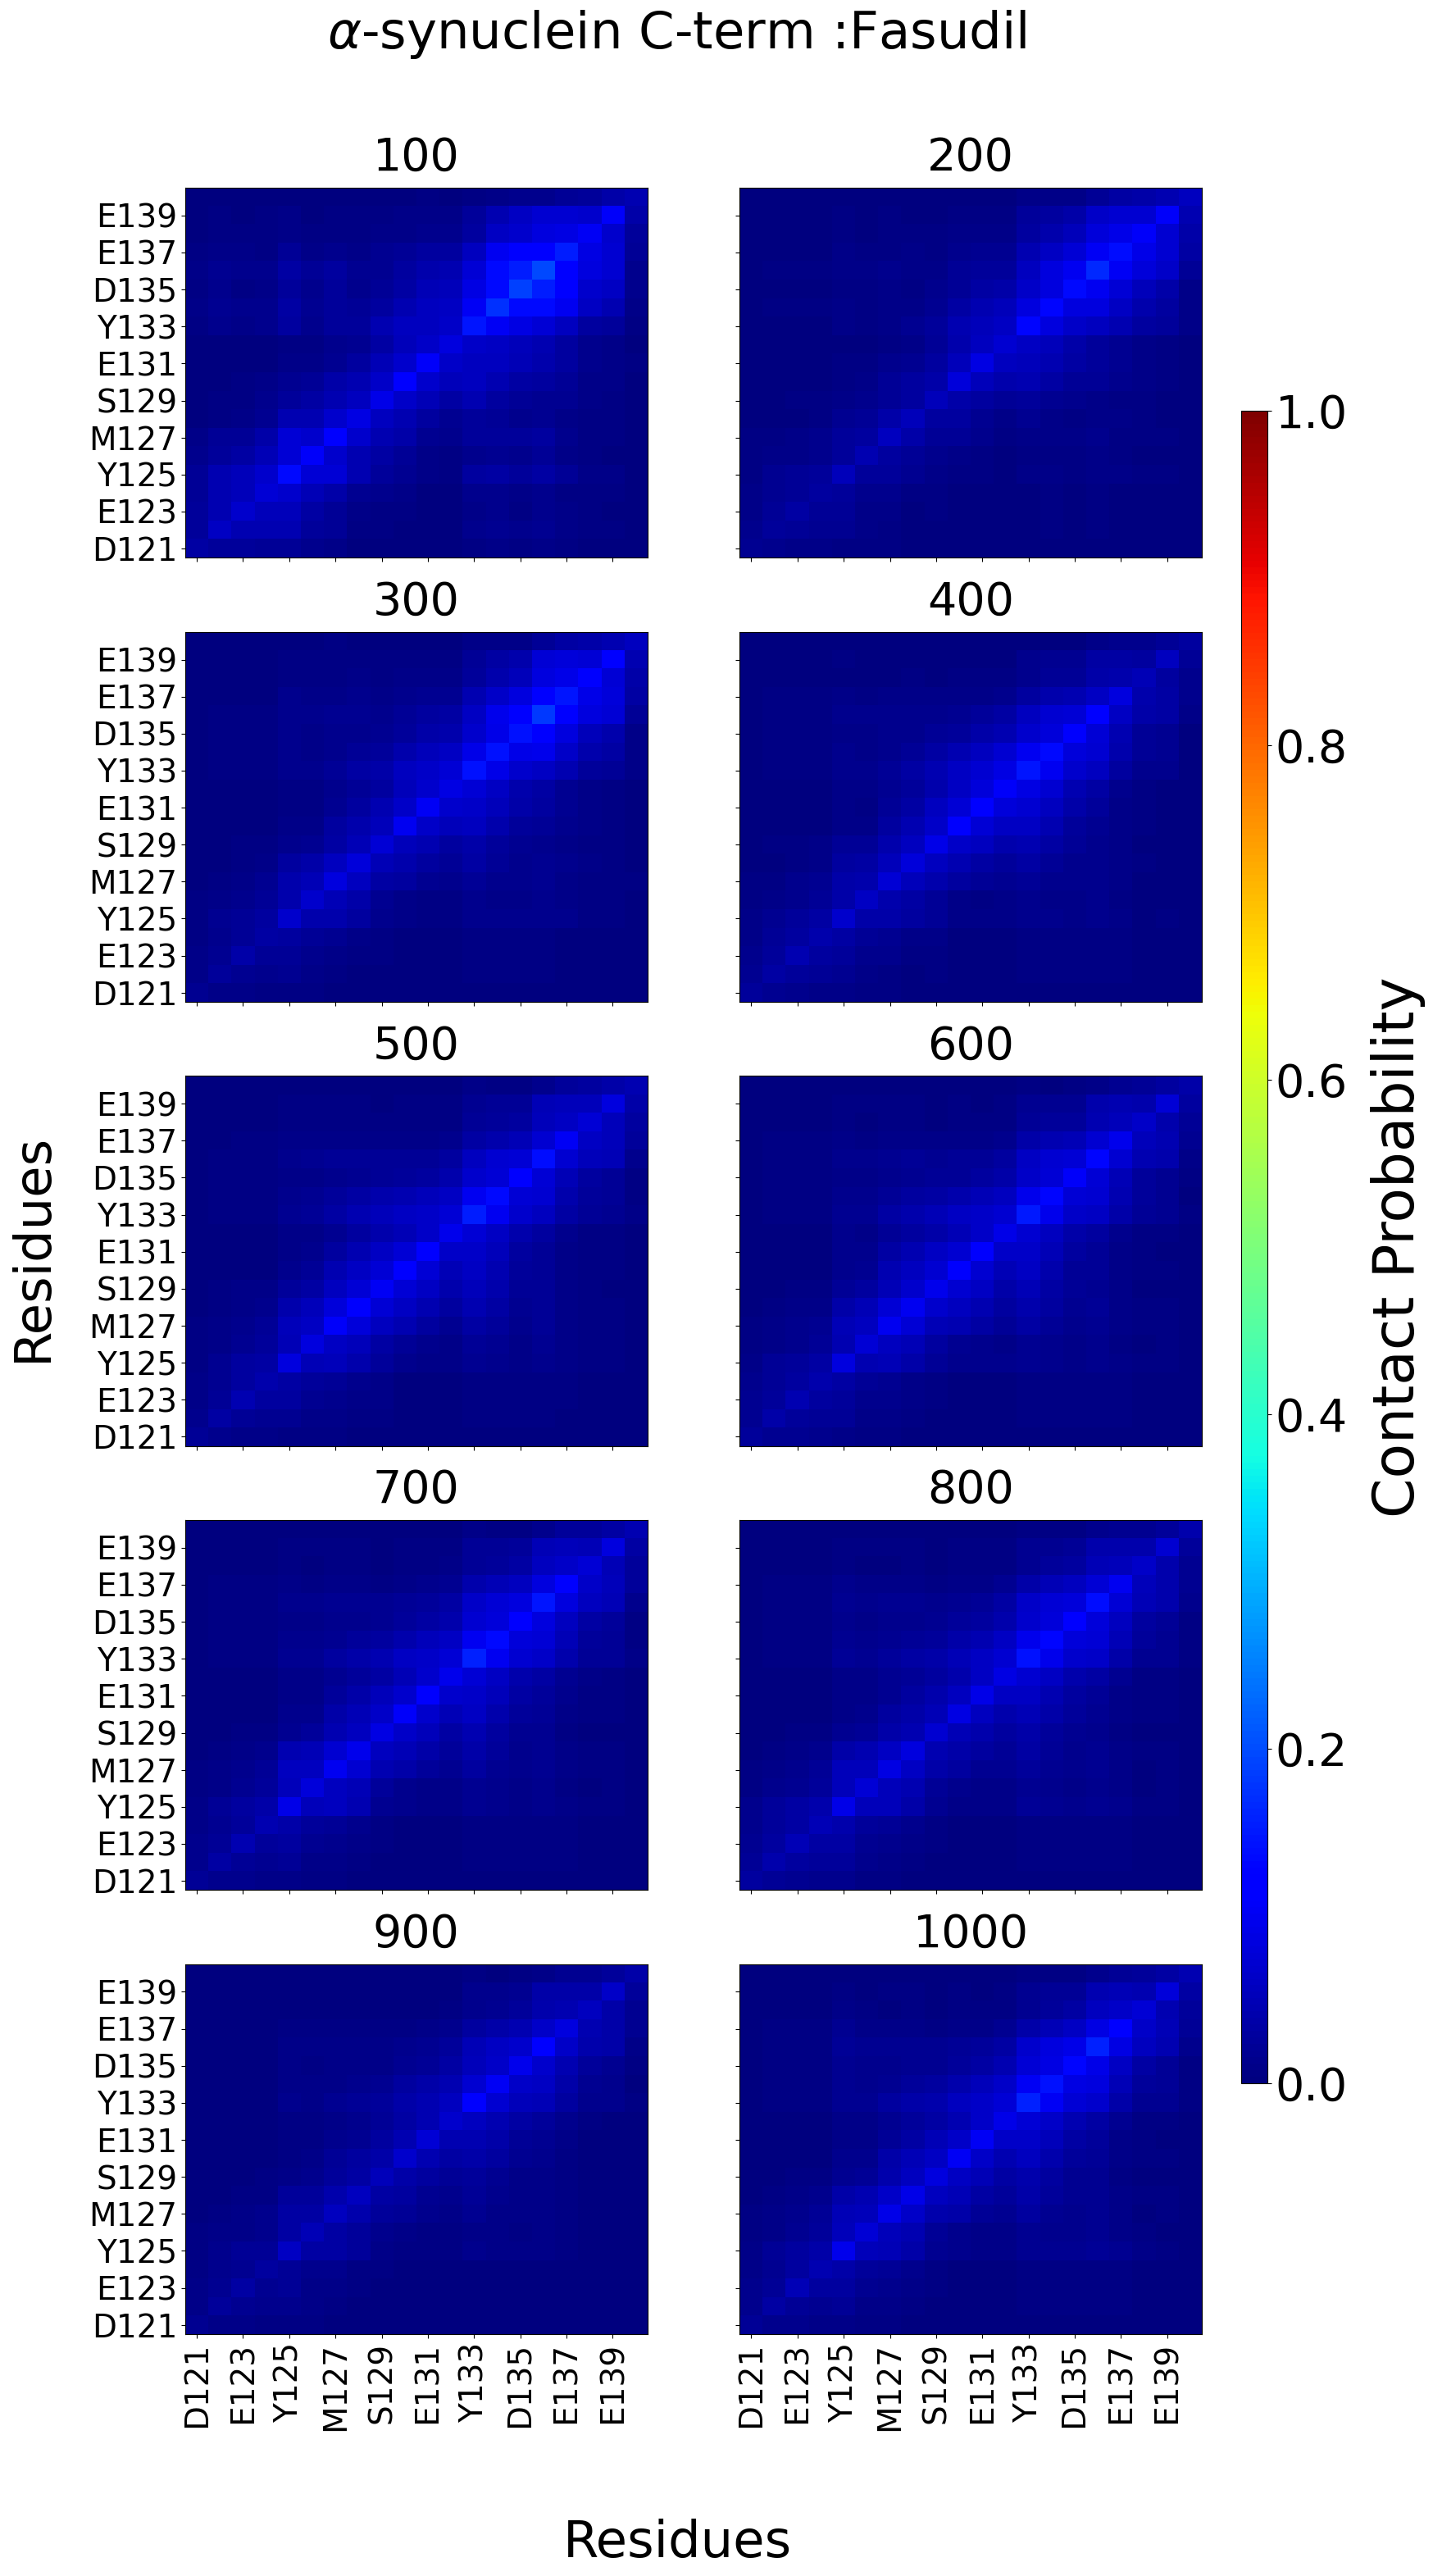

In [20]:
# from mpl_toolkits.axes_grid1 import AxesGrid

fig, axes = plt.subplots(5,2, figsize=(16,34), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(0, 10):
    # ax.set_axis_off()

    contact_map = np.array(lcm_fas_1[i])

    
    p,q = np.unravel_index(i,(5,2))

    im = axes[p,q].imshow(contact_map, vmin=0, vmax=1.0,cmap='jet', aspect='auto')
    axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(range(0, 20,2), ticks_pnum[::2], rotation=90, size=28)
    axes[p,q].set_yticks(range(0, 20,2), ticks_pnum[::2], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{(i*100)+100}',size=40, pad=15)

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Contact Probability", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.03, "Residues", ha="center", fontsize=45)
fig.text(-0.01, 0.5, "Residues", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-synuclein C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')

# plt.show()
# plt.clf()


In [6]:
cm={}
file_name = 'contact_matrix.json'

for i in range(0,1000, 100):

    if i==0:
        cm[i+1000]=load_json(f'{work_directory}/{a[2]}/data/out_{i}/{file_name}')
    else:
        cm[i]=load_json(f'{work_directory}/{a[2]}/data/out_{i}/{file_name}')

        

Text(0.5, 0.93, '$\\alpha$-syn-C-term :Fasudil')

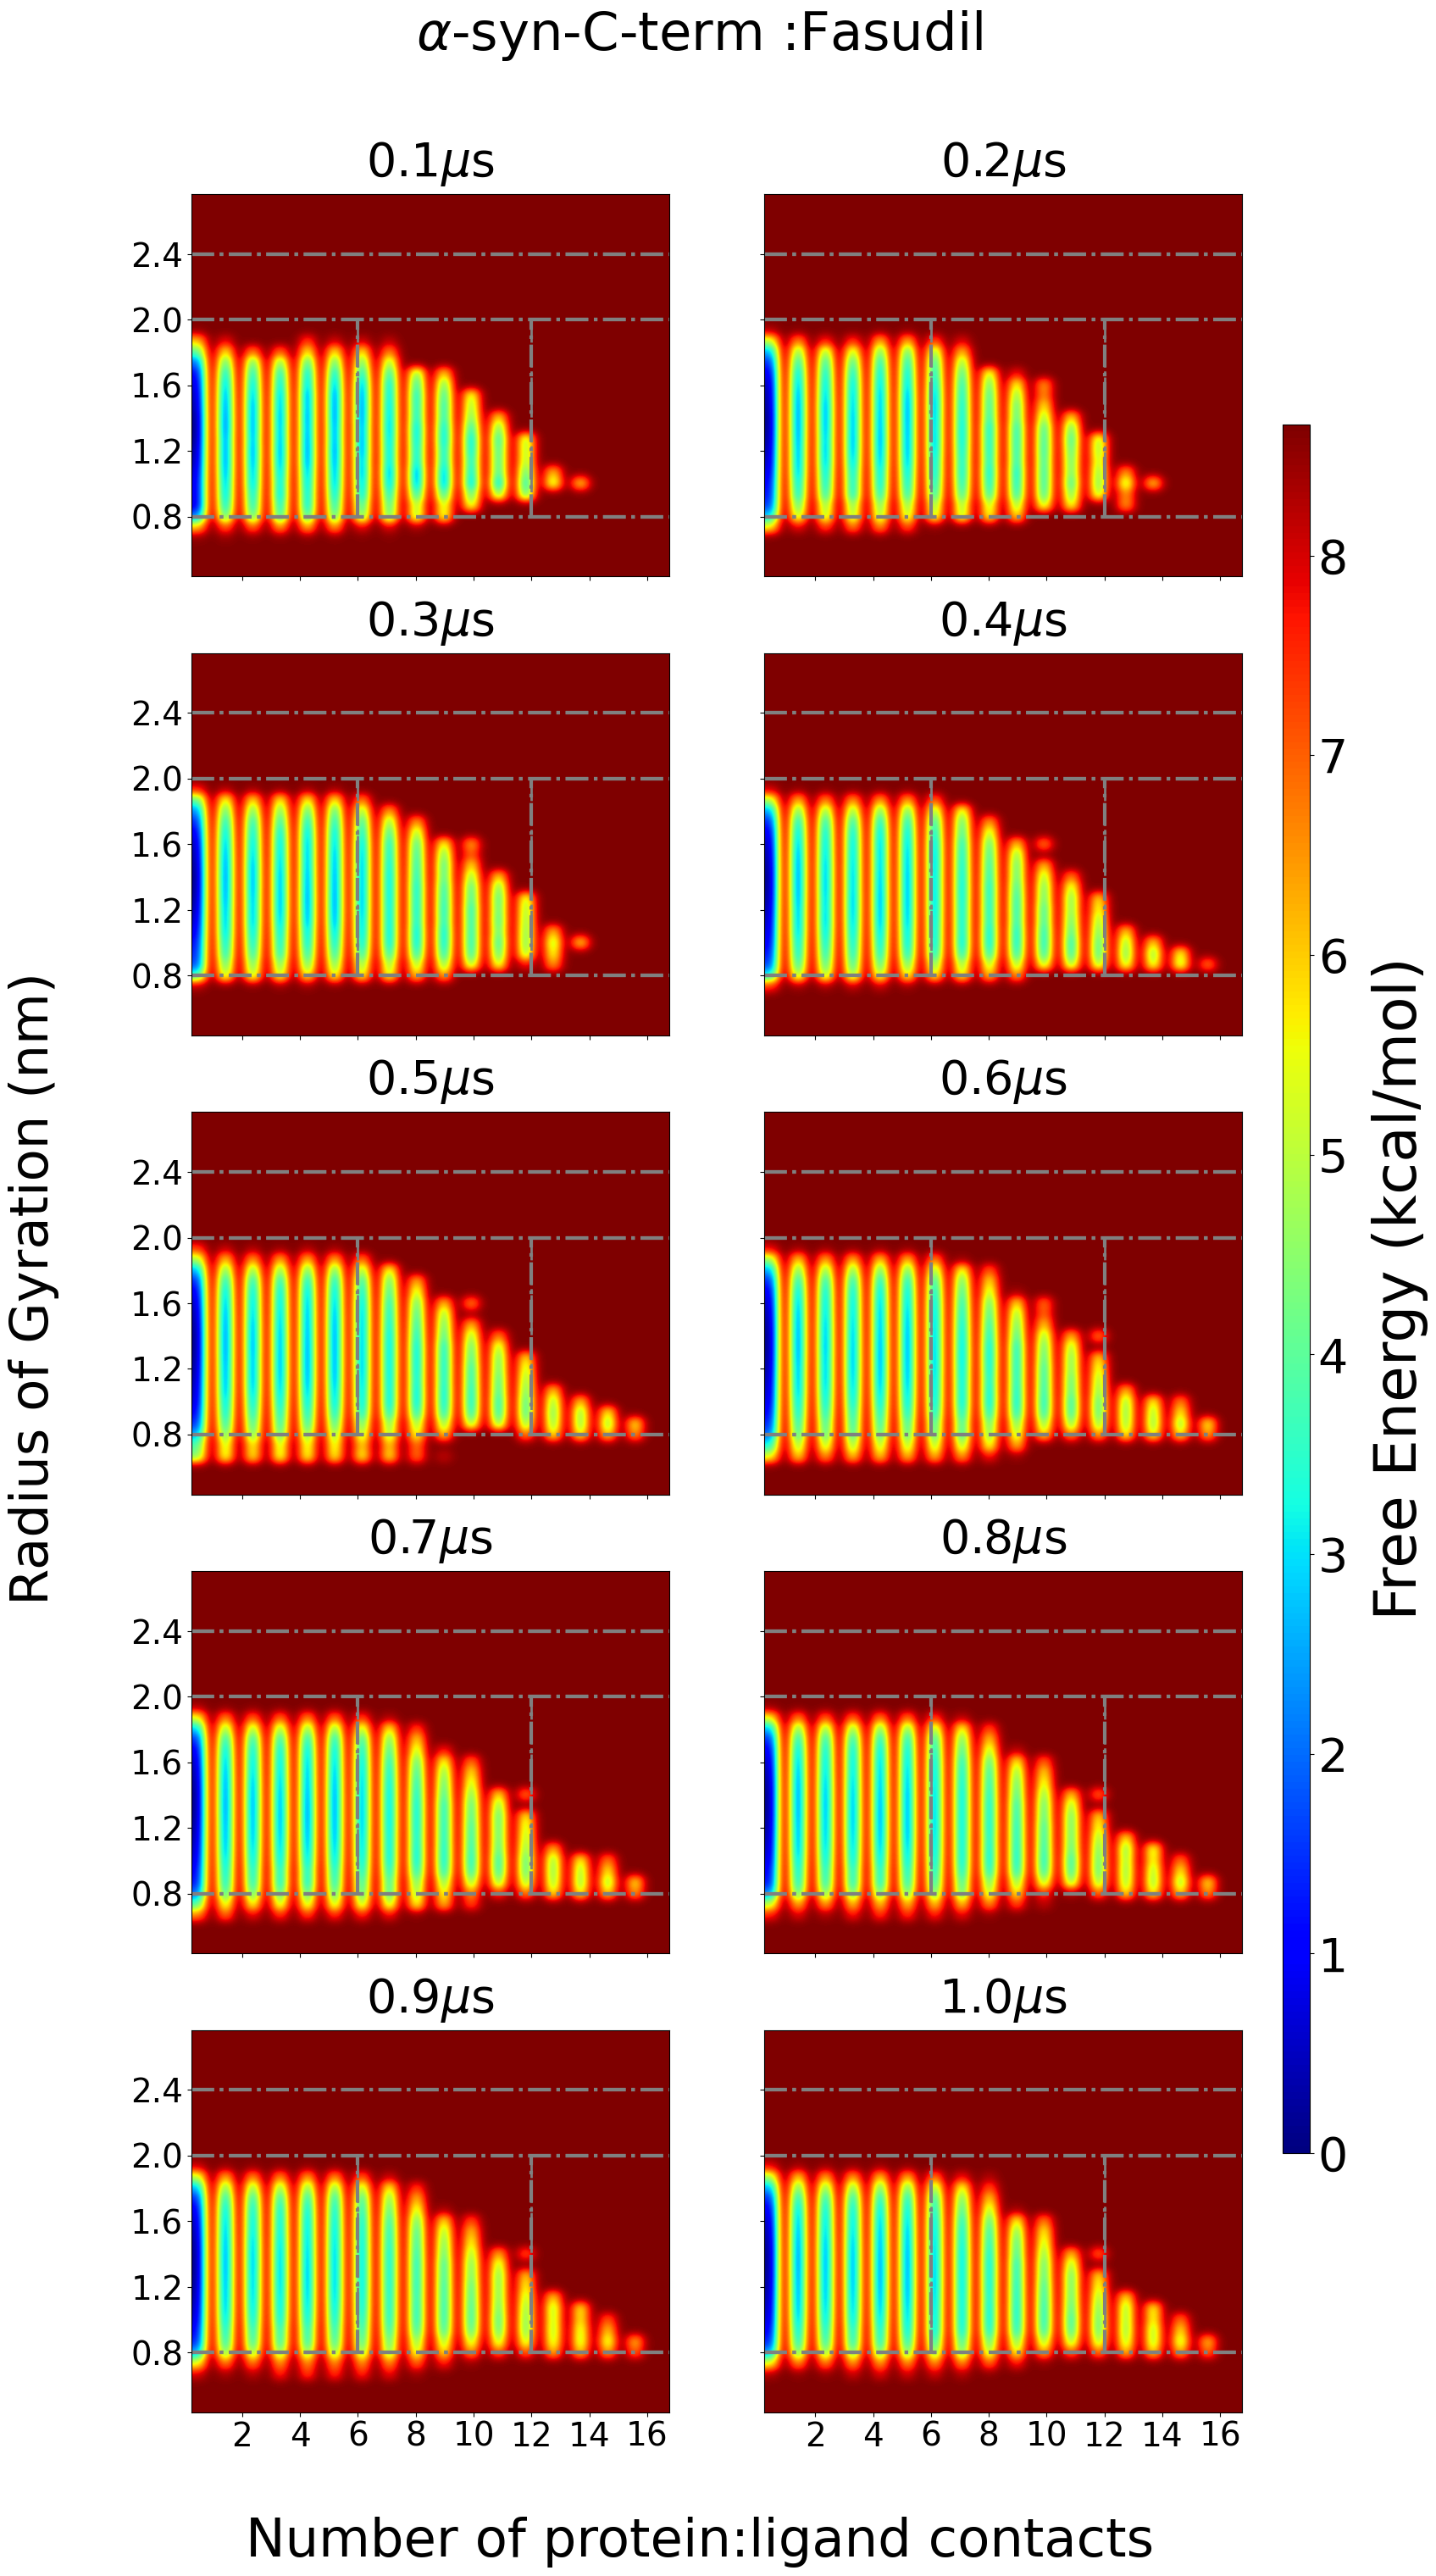

In [21]:
# from mpl_toolkits.axes_grid1 import AxesGrid

histogram_data={}

fig, axes = plt.subplots(5,2, figsize=(16,34), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(100, 1100, 100):
    # ax.set_axis_off()

    fe, xedges,yedges, histogram_data[i]  = free_energy_2D(Y=colvar_data[i].T[index_dict['Rg']], X=np.sum(cm[i]['0'], axis=1),
                                                           T=300,bins=35,
                                                           y0=0.4, ymax=2.8, 
                                                           x0=0, xmax=17,
                                                           weights=weights_norm[i])

    
    p,q = np.unravel_index(int(i/100)-1,(5,2))

    im = axes[p,q].imshow(fe, cmap='jet', aspect='auto',
                          extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                          interpolation='gaussian')
    
    # axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(np.arange(0, 17, 2), np.arange(0, 17, 2), rotation=0, size=28)
    axes[p,q].set_yticks(np.arange(0.4, 3.0, 0.4), [round(i, 1) for i in np.arange(0.4, 3.0, 0.4)], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{i/1000}'+r'$\mu$s',size=40, pad=15)

    axes[p,q].axhline(y=0.8, color='gray', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.0, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.4, color='gray', lw=3, ls='-.')
    axes[p,q].vlines([6,12], 0.8, 2.0, color='gray', lw=2, ls='-.')

    axes[p,q].axhline(y=0.8, color='gray', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.0, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.4, color='gray', lw=3, ls='-.')
    axes[p,q].vlines([6,12], 0.8, 2.0, color='gray', lw=3, ls='-.')

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Free Energy (kcal/mol)", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.06, "Number of protein:ligand contacts", ha="center", fontsize=45)
fig.text(-0.01, 0.5, "Radius of Gyration (nm)", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-syn-C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')

# plt.show()
# plt.clf()


Text(0.5, 0.93, '$\\alpha$-syn-C-term :Fasudil')

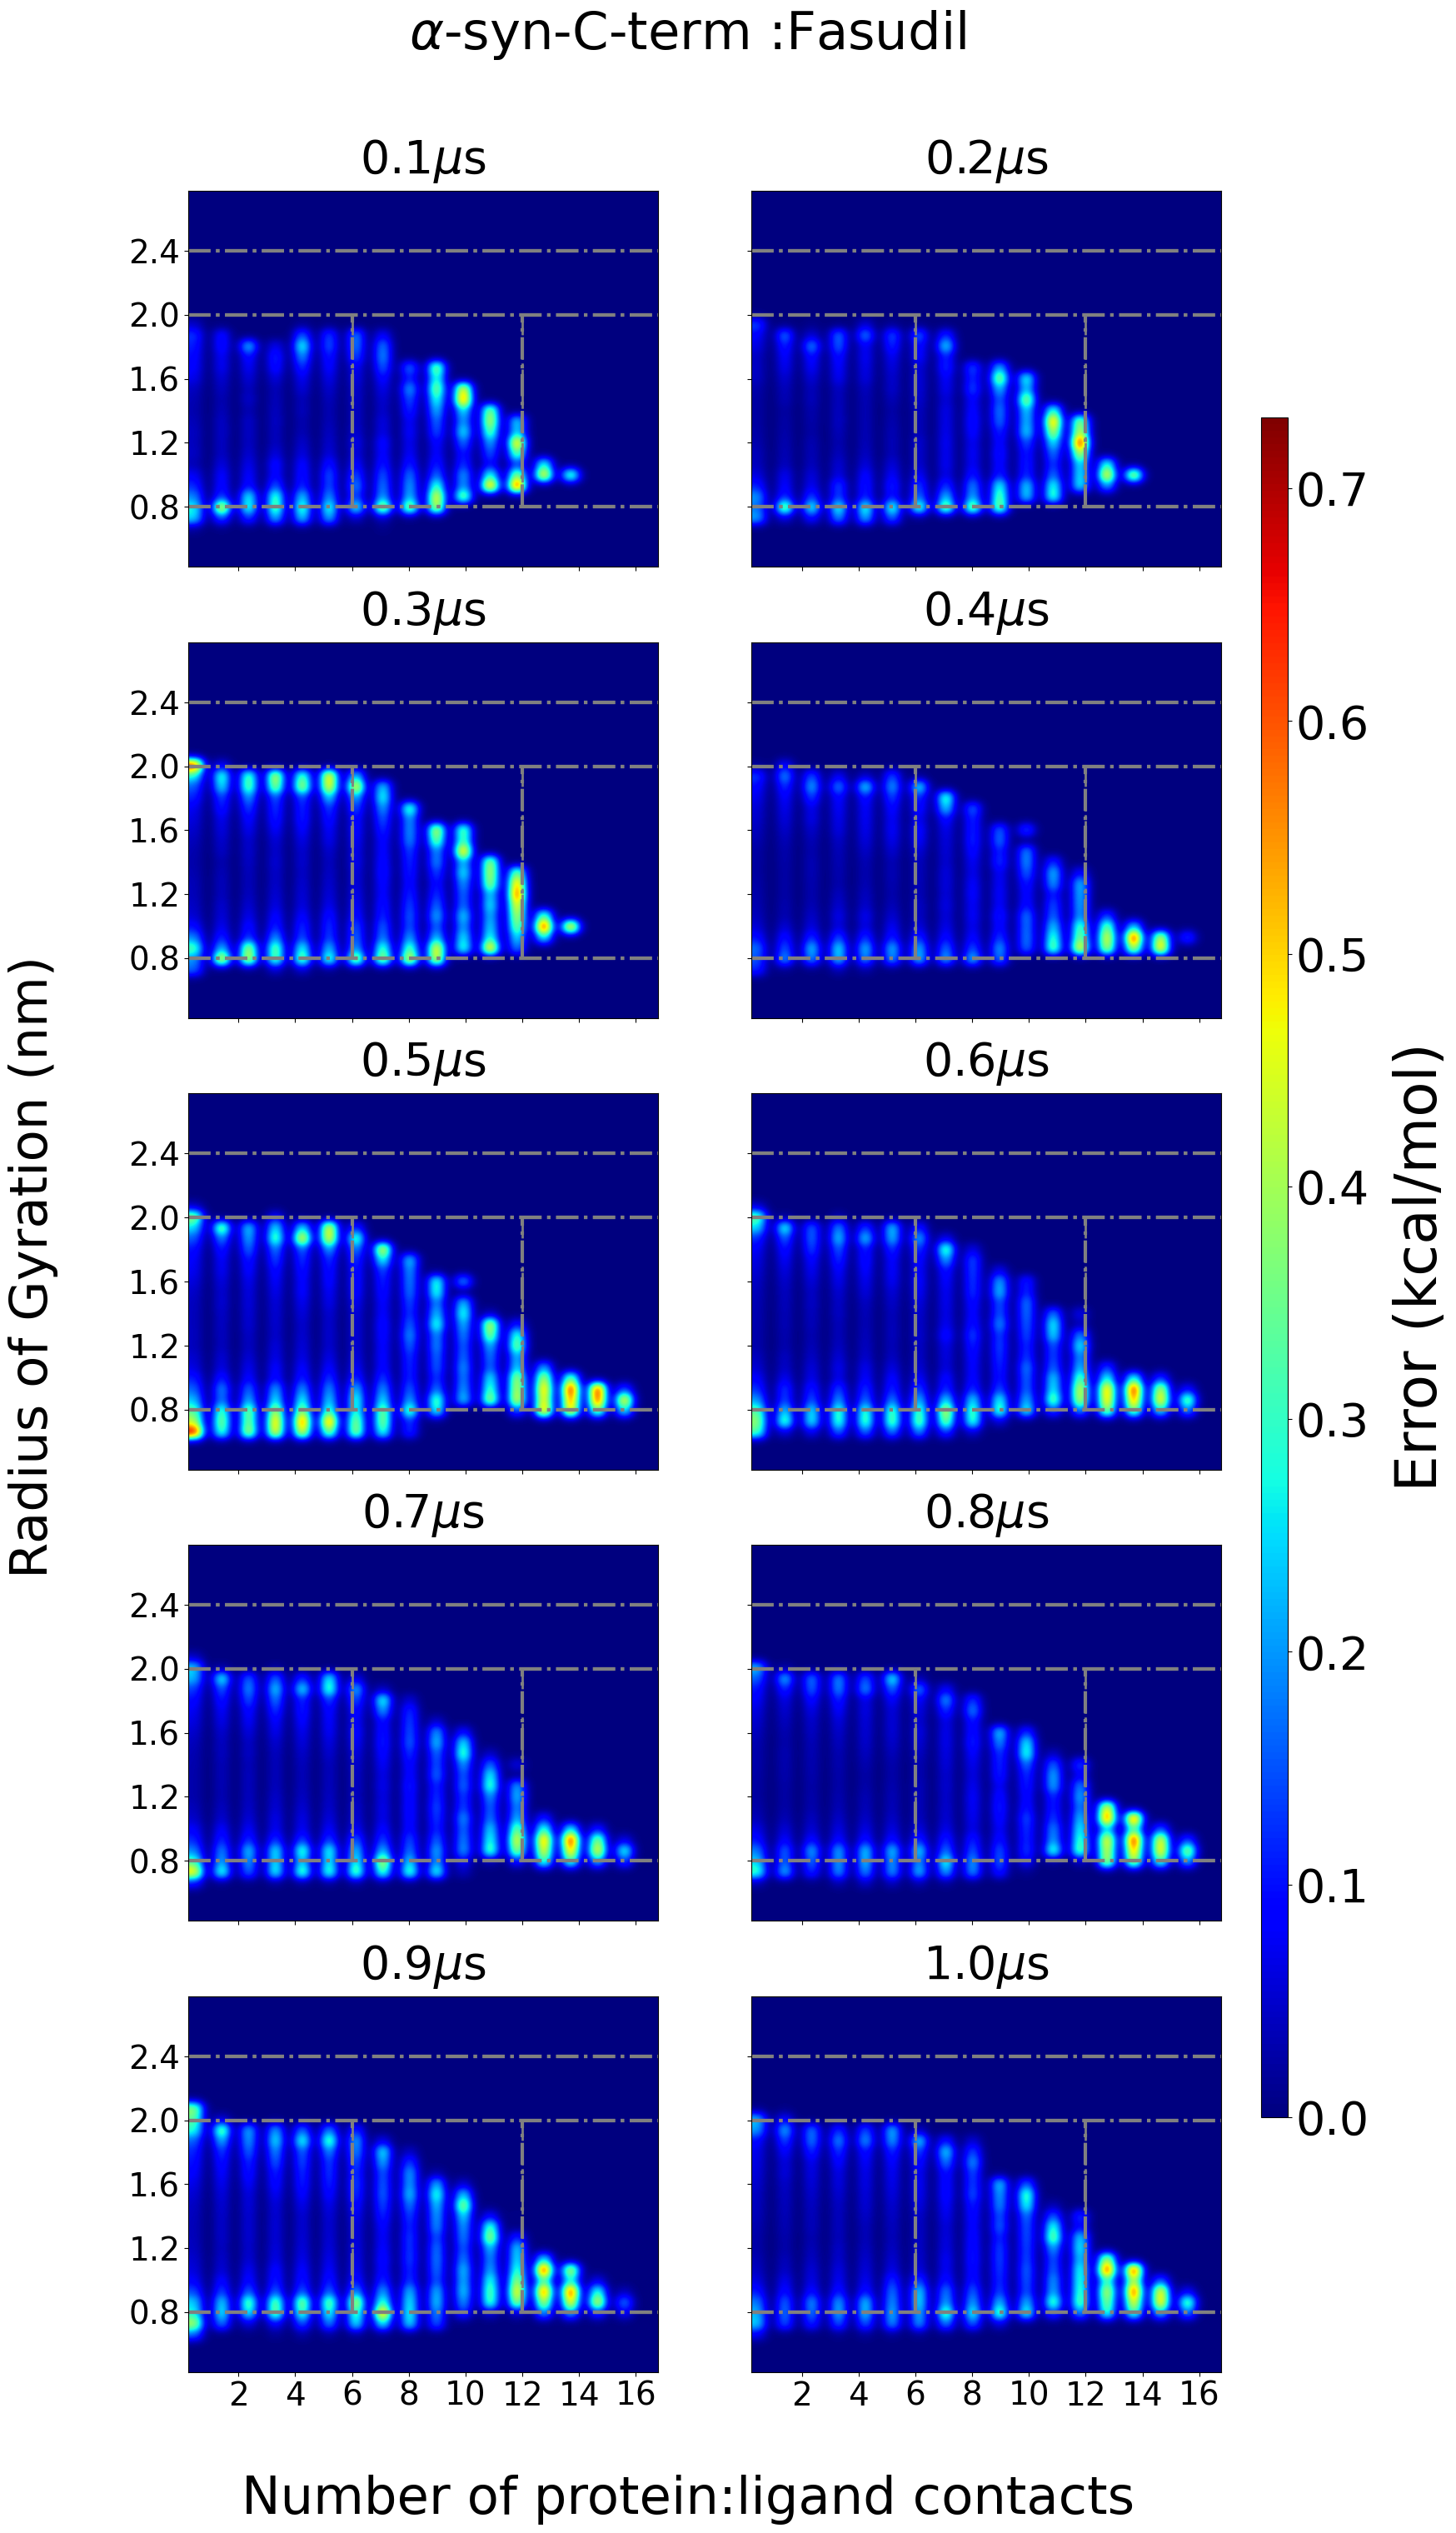

In [22]:
histogram_data={}
mybins=35

fig, axes = plt.subplots(5,2, figsize=(16,34), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(100, 1100, 100):

    args={'X' : np.sum(cm[i]['0'], axis=1),
        'Y' : colvar_data[i].T[index_dict['Rg']],
        'bin_count' : mybins,
        'y0' : 0.4,
        'ymax' : 2.8,
        'x0' : 0,
        'xmax' : 17,
        'weights' : weights_norm[i]}
        
    # ax.set_axis_off()

    # fe, xedges,yedges, histogram_data[i], err  = free_energy_2D_blockerror(Y=colvar_data[i].T[index_dict['Rg']], X=np.sum(cm[i]['0'], axis=1),
    #                                                        T=300,bins=35,
    #                                                        y0=0.4, ymax=2.8, 
    #                                                        x0=0, xmax=17,
    #                                                        weights=weights_norm[i])

    bootstrap_results, xcenters, ycenters = blocking_bootstrap_2d_fe(**args) 

    p,q = np.unravel_index(int(i/100)-1,(5,2))
    im = axes[p,q].imshow(np.flipud(bootstrap_results.standard_error.reshape(35,35)), cmap='jet', aspect='auto',
                          extent=[ycenters[0], ycenters[-1], xcenters[0], xcenters[-1]],
                          interpolation='gaussian')
    
    # axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(np.arange(0, 17, 2), np.arange(0, 17, 2), rotation=0, size=28)
    axes[p,q].set_yticks(np.arange(0.4, 3.0, 0.4), [round(i, 1) for i in np.arange(0.4, 3.0, 0.4)], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{i/1000}'+r'$\mu$s',size=40, pad=15)

    axes[p,q].axhline(y=0.8, color='gray', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.0, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.4, color='gray', lw=3, ls='-.')
    axes[p,q].vlines([6,12], 0.8, 2.0, color='gray', lw=2, ls='-.')

    axes[p,q].axhline(y=0.8, color='gray', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.0, color='gray', lw=3, ls='-.')
    axes[p,q].axhline(y=2.4, color='gray', lw=3, ls='-.')
    axes[p,q].vlines([6,12], 0.8, 2.0, color='gray', lw=3, ls='-.')

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Error (kcal/mol)", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.06, "Number of protein:ligand contacts", ha="center", fontsize=45)
fig.text(-0.01, 0.5, "Radius of Gyration (nm)", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-syn-C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')

# plt.show()
# plt.clf()

In [14]:
def fe_regions(x, y):
    return np.stack([
        (x >= 0.4) & (x <  0.8) & (y >= 0) & (y <= 18),
        (x >= 0.8) & (x <= 2.0) & (y >= 0) & (y < 6),
        (x >= 0.8) & (x <= 2.0) & (y >= 6) & (y < 12),
        (x >= 0.8) & (x <= 2.0) & (y >= 12) & (y <= 18),
        (x > 2.0) & (x <= 2.4) & (y >= 0) & (y <= 18)
        
    ]).astype(int)

In [15]:
quad_data=[]


for i in range(100, 1100, 100):
    # ax.set_axis_off()

    q_temp=[]
    Y=colvar_data[i].T[index_dict['Rg']]
    X=np.sum(cm[i]['0'], axis=1)


    q = fe_regions(x=Y, y=X)
    # print(q)
    for j in range(len(q)):

        q_boot_mean , q_boot_er = get_blockerror_pyblock_nanskip_rw_(q[j], weights=weights_norm[i] )
        q_temp.append([q_boot_mean , q_boot_er])
    quad_data.append(q_temp)


quad_data=np.array(quad_data)

In [16]:
quad_data.shape

(10, 5, 2)

In [25]:
import pandas as pd

df = pd.DataFrame(quad_data[:, :, 0].round(5)*100, columns=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

df.insert(0, r'Simulation Time(micro-s)', [f"{i/1000}" for i in range(100, 1100, 100)])
df.insert(2, 'Q1 err', [f"{t*100:.5f}" for t in quad_data.T[1][0]])
df.insert(4, 'Q2 err', [f"{t*100:.5f}" for t in quad_data.T[1][1]])
df.insert(6, 'Q3 err', [f"{t*100:.5f}" for t in quad_data.T[1][2]])
df.insert(8, 'Q4 err', [f"{t*100:.5f}" for t in quad_data.T[1][3]])
df.insert(10, 'Q5 err', [f"{t*100:.5f}" for t in quad_data.T[1][4]])

In [26]:
itables.show(df,columnDefs=[
        {"className": "center-column", "targets": [1]} # targets refers to the 0-indexed column number
    ], classes="display nowrap cell-border")
